# 01 · reward 从来没有非零过

**对应 HANDOFF §6 P0**「验 backward + docking + **reward** 全链路」。

前两项通过了。**第三项没有。** 全链路能跑 ≠ reward 有效，而这道关卡当初
被记成通过，是因为没有人去读 reward 本身的取值。

这是目前**最严重**的未完成项：它不修，§6 P2 的 16 个 run 跑完也只是
拿到零梯度。


In [1]:
%matplotlib inline
import json, warnings
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": .25,
    "axes.spines.top": False, "axes.spines.right": False,
})
R = Path("/lus/lfs1aip2/projects/public/u6gb/tasks/large-discovery-model/ldm_rl/results")
def load(name): return json.loads((R / name).read_text())

aud = load("reward_audit.json")
print(f'{aud["n_runs"]} 个 run · {aud["n_rewards_total"]} 个 reward 取值 · '
      f'其中超过 1e-6 的：{aud["n_above_1e6_total"]}')

31 个 run · 479 个 reward 取值 · 其中超过 1e-6 的：0


## 图 1 — 每个 run 的 reward 最大绝对值

红色虚线是 `1e-6`。**没有一个 run 越过它。**

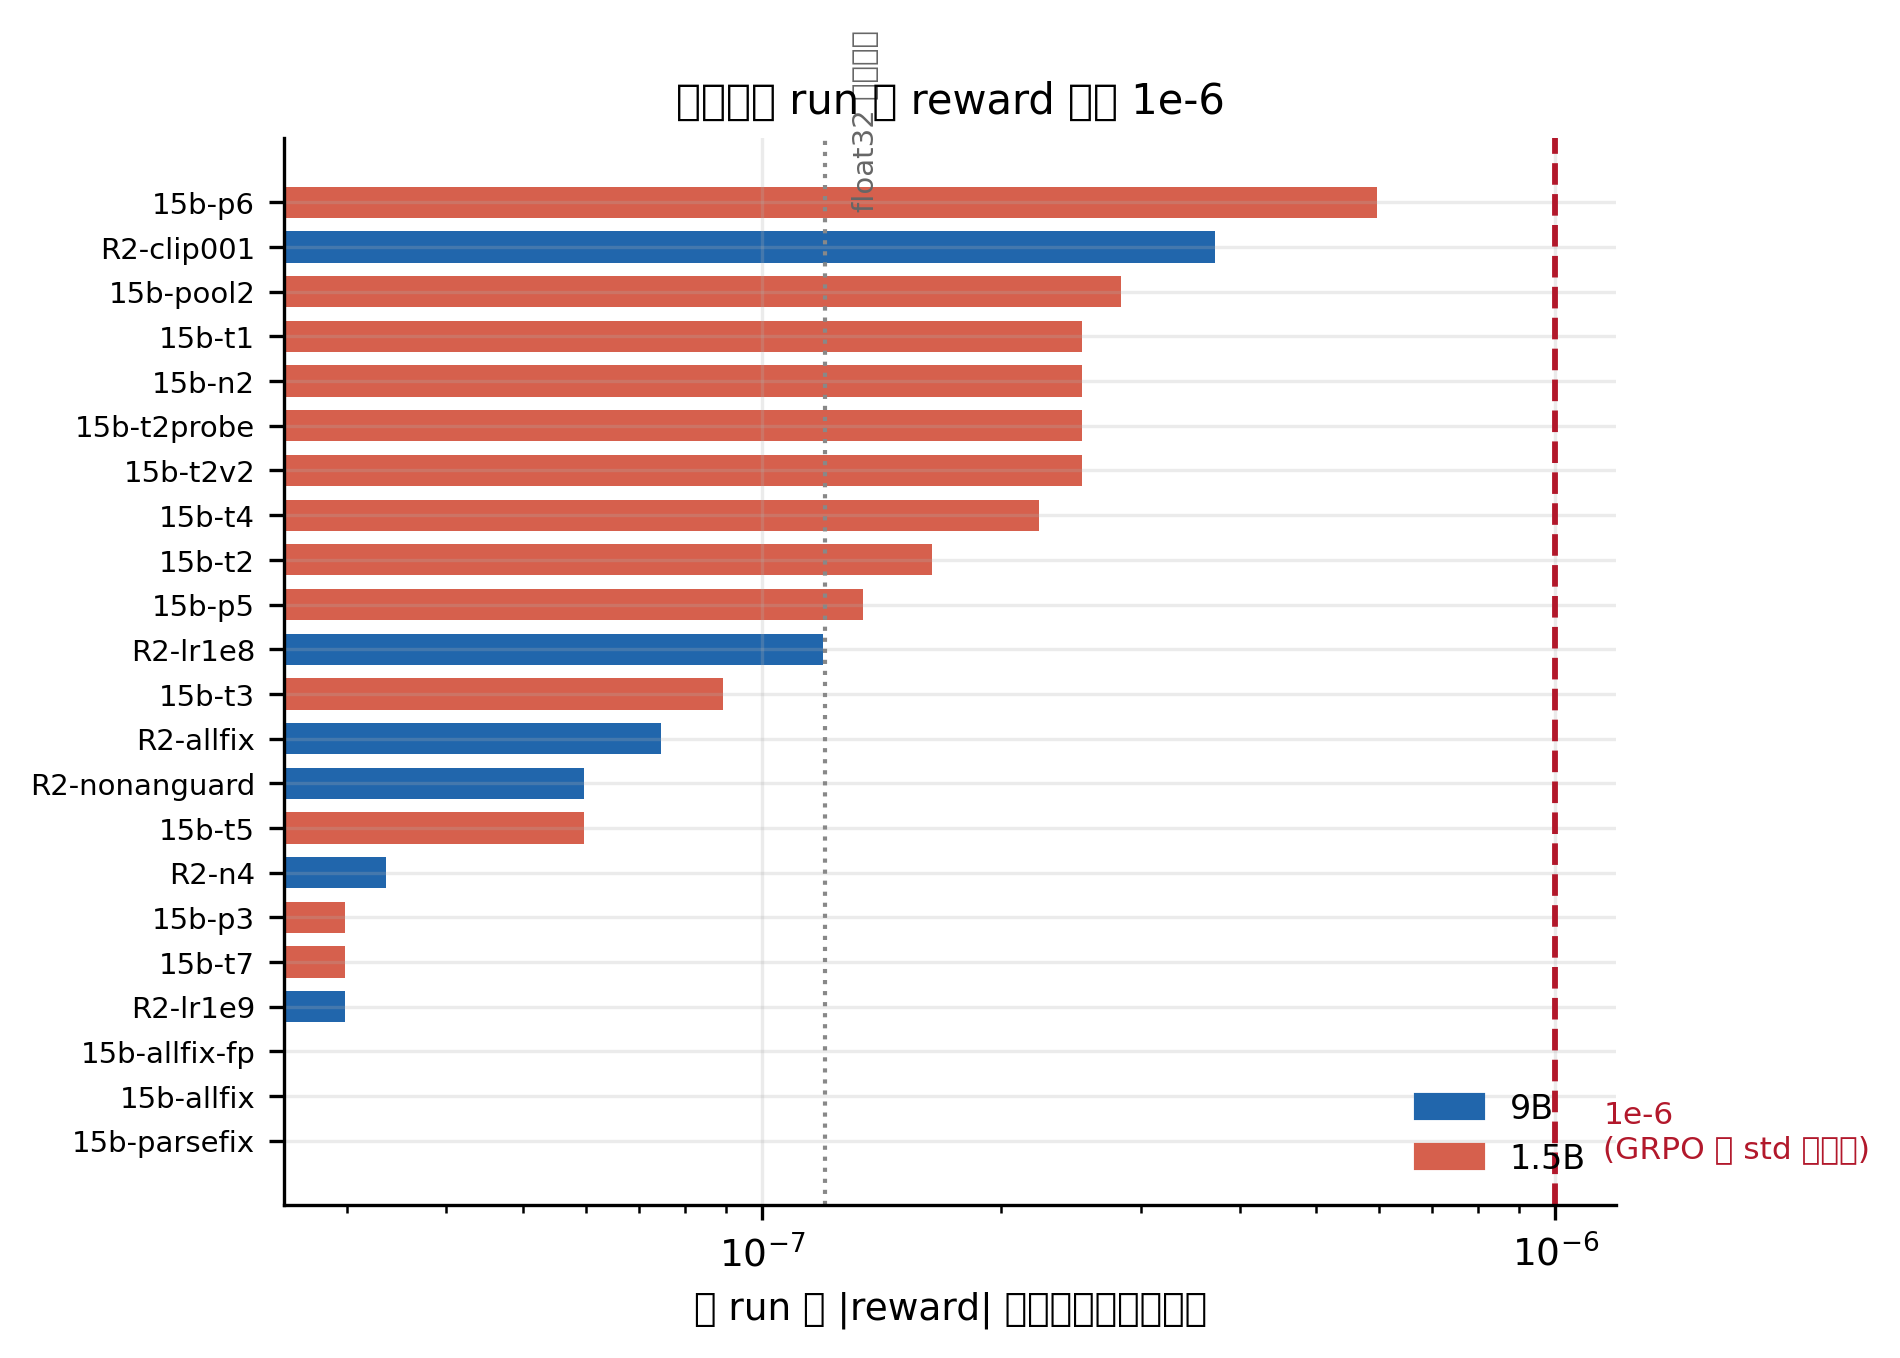

In [2]:
runs = aud["runs"]
runs = sorted(runs, key=lambda r: -r["max_abs"])[:22]
fig, ax = plt.subplots(figsize=(6.4, 4.6))
col = {"9B": "#2166ac", "1.5B": "#d6604d"}
y = np.arange(len(runs))
ax.barh(y, [r["max_abs"] for r in runs],
        color=[col[r["size"]] for r in runs], height=.7)
ax.set_yticks(y); ax.set_yticklabels([r["run"][:24] for r in runs], fontsize=7)
ax.invert_yaxis(); ax.set_xscale("log")
ax.axvline(1e-6, ls="--", lw=1.4, color="#b2182b")
ax.text(1.15e-6, len(runs) - .5, "1e-6\n(GRPO 的 std 保护值)", fontsize=7.5,
        color="#b2182b", va="bottom")
ax.axvline(1.2e-7, ls=":", lw=1, color="#888888")
ax.text(1.3e-7, .2, "float32 机器精度", fontsize=7, color="#666666", rotation=90, va="bottom")
ax.set_xlabel("该 run 里 |reward| 的最大值（对数轴）")
ax.set_title("没有一个 run 的 reward 越过 1e-6", fontsize=10)
h = [plt.Rectangle((0,0),1,1,color=col[k]) for k in ("9B","1.5B")]
ax.legend(h, ["9B","1.5B"], frameon=False, fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

**读法**：条形全部落在红线左侧，而且大多贴着灰色虚线（float32 精度）。
量级上这些值就是 0。

GRPO 用组内 reward 的标准差归一化 advantage；全零组等于除以 ~0。
slime 的 `+1e-6` 保护让它不发散——**所以训练不会报错，loss 有数字，
曲线在动，GP 池在增长**，每一个平时用来判断「在训练」的信号都正常。

## 图 2 — 为什么是零：round 0 之后模型不再输出 JSON

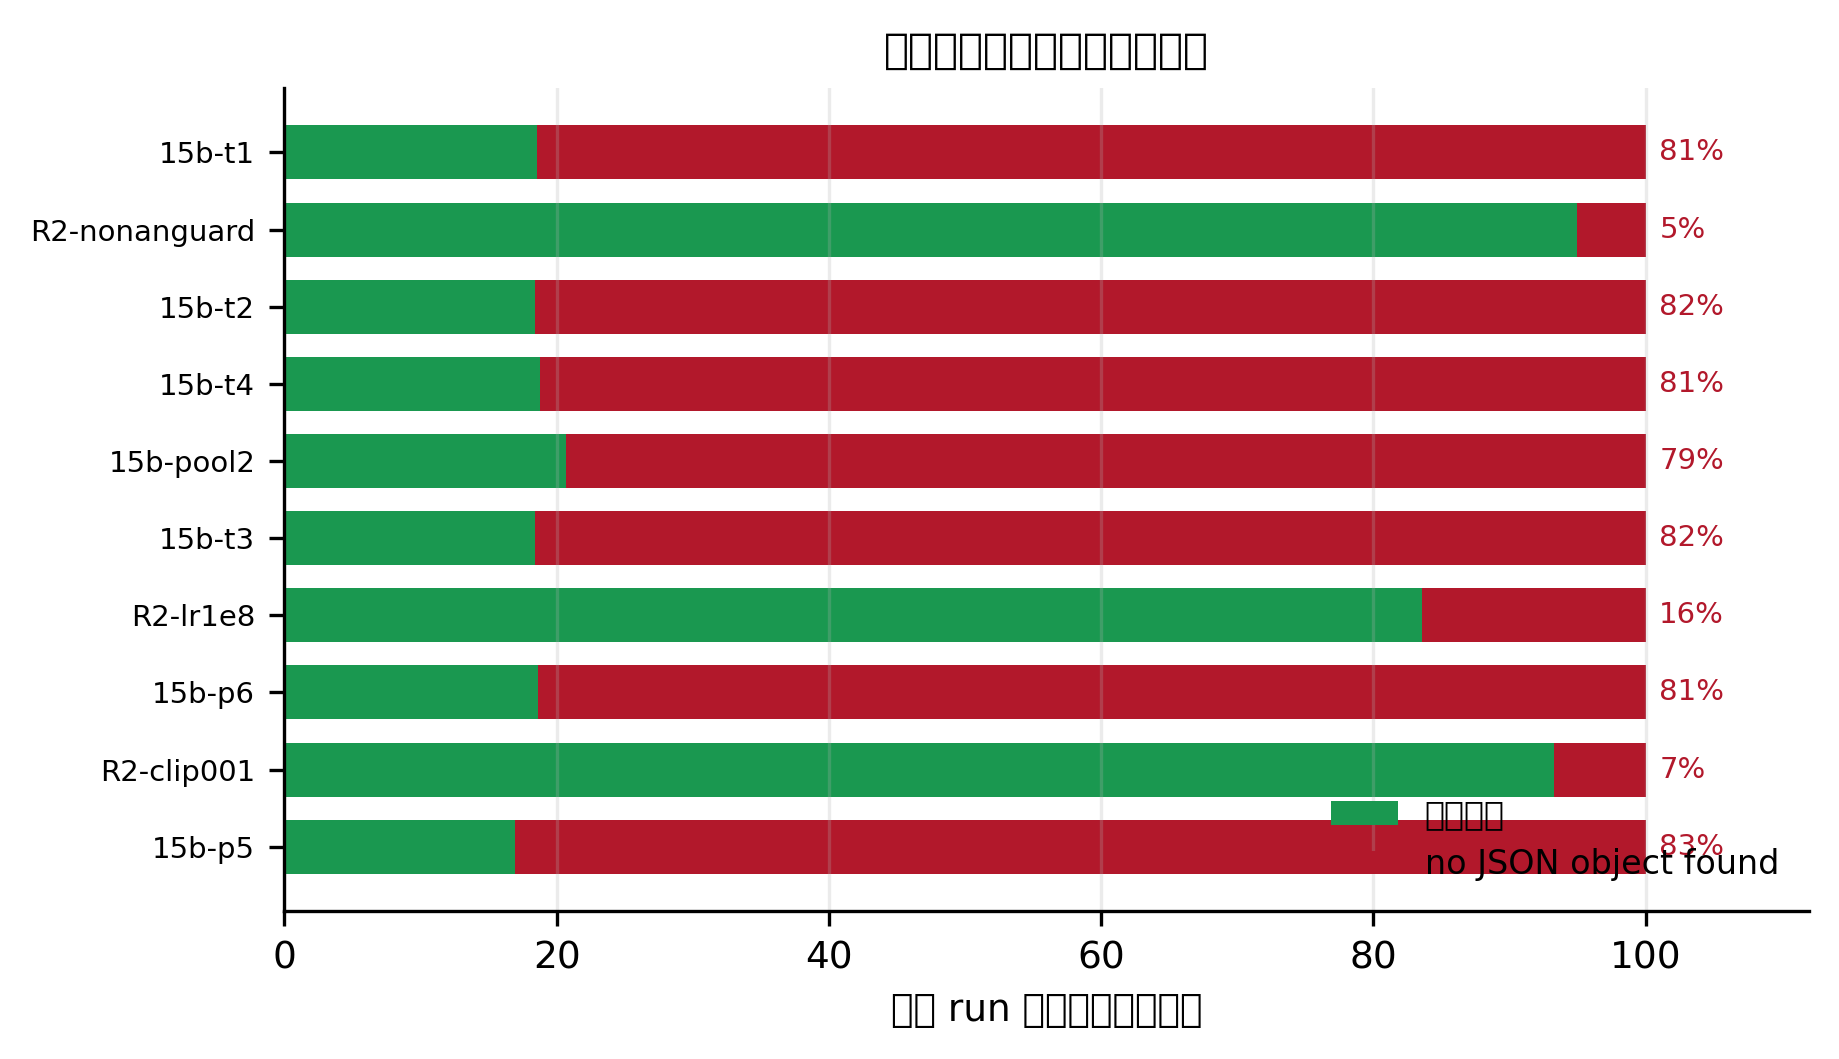

In [3]:
sub = [r for r in aud["runs"] if r["n_parse_fail"] + r["n_succeeded"] >= 20]
sub = sorted(sub, key=lambda r: -(r["n_parse_fail"] + r["n_succeeded"]))[:10]
fig, ax = plt.subplots(figsize=(6.2, 3.6))
y = np.arange(len(sub))
ok = np.array([r["n_succeeded"] for r in sub], float)
bad = np.array([r["n_parse_fail"] for r in sub], float)
tot = ok + bad
ax.barh(y, 100*ok/tot, color="#1a9850", height=.7, label="成功评测")
ax.barh(y, 100*bad/tot, left=100*ok/tot, color="#b2182b", height=.7, label="no JSON object found")
for i, r in enumerate(sub):
    ax.text(101, i, f'{100*bad[i]/tot[i]:.0f}%', va="center", fontsize=7, color="#b2182b")
ax.set_yticks(y); ax.set_yticklabels([r["run"][:22] for r in sub], fontsize=7)
ax.invert_yaxis(); ax.set_xlim(0, 112); ax.set_xlabel("占该 run 全部轮次的百分比")
ax.set_title("解析失败吃掉了绝大多数轮次", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="lower right"); ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

**读法**：红色是 `no JSON object found`。它不是偶发——在跑得最久的 run 上
占到 **八成以上**。没有候选就没有 predictions，`_acquisition_reward` 走
`if not scores: return 0.0`，于是 reward 精确等于 0。

## 根因：环境观测破坏了 chat 格式

日志里 `Finish rollout` 带着模型的**实际输入**，长这样：

```
{"direct_smiles": [...]}<|im_end|><round 0>
Received 2 candidate proposal(s).
- mol-19efc8c41e45: SUCCEEDED metrics={"activity": 6.707, "vina": -5.005}
Best so far: 1 successful evaluation(s); no single best with multiple objectives.
Propose the next candidates.<|im_end|><round 1>
Your response could not be parsed as a proposal: no JSON object found
```

`rl/ldm_rl/bridge.py` 里是 `response += step.observation` ——
**观测直接接在 `<|im_end|>` 后面，没有 `<|im_start|>user` 包裹**。
对 Qwen 的 chat template 来说，`<|im_end|>` 之后必须是新的角色标记，
直接跟正文是格式错误。

形态完全吻合：

| | 结果 | 为什么 |
|---|---|---|
| **round 0** | 永远成功 | 那一轮的 prompt 走了 `_apply_chat_template`，格式正确 |
| **round 1 及以后** | 全部失败 | 模型输出里连 `{` 都没有 |


## 排除掉的两个解释

两个都听起来合理，一次实测全否掉（`code/probe_acq_reward.py`）：

In [4]:
e = load("ehvi_vs_history.json")
rows = [{"历史点数": p["n_history"], "EHVI 中位数": f'{p["median"]:.3e}',
         "EHVI 最大": f'{p["max"]:.3e}', ">1e-6": f'{p["n_above_1e6"]}/8',
         "fallback_reason": "None"} for p in e["points"]]
pd.DataFrame(rows).style.hide(axis="index")

历史点数,EHVI 中位数,EHVI 最大,>1e-6,fallback_reason
41,4.441e-02,1.058e-01,8/8,None
63,1.794e-02,5.390e-02,7/8,None
120,1.098e-02,3.840e-02,7/8,None
300,0.000e+00,2.080e-02,2/8,None


- **不是「GP 失败走了 fallback」**：`fallback_reason` 在每个点都是 `None`。
  （`ehvi_all.py:83` 确实有 `except Exception: return _fallback(...)` 返回
  `np.zeros`，形态吻合得很好——但证据说不是它。）
- **不是「EHVI 本来就该是 0」**：在 RL 实际运行的 63–120 历史点上，
  EHVI 是 **1e-2 量级**，与 reward 读到的差**六个数量级**。
  候选还是从池子里采的，而池子里 1493 个分子本身就是模型生成的，
  所以「模型生成的分子太差」也排除了。

## 修复状态

已写好（`bridge.py` 的 `_observation_wrapper`），用 tokenizer 自己的
chat template 生成包裹而非硬编码：

```
prefix = '<|im_end|>\n<|im_start|>user\n'
suffix = '<|im_end|>\n<|im_start|>assistant\n<think>\n'
```

61 个单元测试仍全过，tokenizer 没有 chat template 时退回旧行为。

**但还没有在真实 run 上验证**——判定标准先写在这里，避免事后解释：
**解析失败率应从 81.6% 显著下降，且 reward 出现 >1e-6 的取值。**
如果失败率没动，说明格式不是唯一原因，要回到候选 id 匹配那条路径上查。